# Fase 1: Limpieza y Estandarización de Datos (Data Wrangling)
**Proyecto:** Investigación diagnóstica y documental del perfil académico
**Objetivo de esta fase:** Importar la matriz general de la cohorte estudiantil, tratar los valores nulos (NaN) en las variables discretas y homologar las variables categóricas para garantizar la precisión del análisis estadístico ex post facto.

In [3]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [13]:
# Importación de la librería fundamental para análisis de datos estructurados
import pandas as pd
import numpy as np

# Carga del dataset general
df = pd.read_excel('datos_generales.xlsx')

# Visualización rápida de la estructura y dimensiones del DataFrame
print("Dimensiones del dataset:", df.shape)
df.head(3)

Dimensiones del dataset: (25, 26)


,anio_escolar,num_control,nombre,genero,tecnico_bachillerato,icpc,innovatec,emprendimiento,verano_ciencia,expo_academica,...,prom_matematicas,prom_programacion,prom_bd,prom_redes,prom_industria,prom_proyecto,idiomas,exp_lab_otra,exp_lab_tics,hobbies
0,2027,TI23110192,Jesús López Silva,Masculino,informatica,5,0,1,2,5,...,96.50,98.6,97.3,94.0,97.50,95.80,2,2,1,3
1,2027,TI23110213,Daniel Salas Flores,Masculino,general,5,0,0,2,5,...,87.10,95.5,94.0,91.0,96.00,91.00,2,1,2,5
2,2027,CTI2211803,Christopher Jimenez Hurtado,Masculino,programacion,0,0,0,2,0,...,85.88,90.0,92.5,89.0,88.25,93.63,2,2,1,1


### 1.1 Estandarización de texto
Para evitar duplicidad de categorías por errores tipográficos o espacios invisibles, se normalizan las columnas categóricas a minúsculas y se eliminan espacios periféricos.

In [15]:
# Columnas categóricas con nombres simplificados
columnas_texto = ['estatus_academico', 'genero', 'tecnico_bachillerato']

# Convertir a minúsculas y aplicar strip
for col in columnas_texto:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().str.strip()

### 1.2 Tratamiento de variables discretas (Conteos)
En la recolección de datos, la ausencia de participación en eventos académicos se registró como celdas vacías (NaN). Metodológicamente, se imputa el valor `0` para no sesgar el cálculo de la media y la mediana del grupo.

In [16]:
# Lista de variables discretas actualizada 
columnas_conteo = [
    'icpc', 'innovatec', 'emprendimiento', 'verano_ciencia', 
    'expo_academica', 'publicaciones', 'cursos', 
    'certificaciones', 'proyectos_prototipo', 'exposiciones_clase'
]

# Lista de variables ordinales/complementarias que también deben ser enteros
columnas_complementarias = [
    'idiomas', 'exp_lab_otra', 'exp_lab_tics', 'hobbies'
]

# Unimos ambas listas para limpiarlas de un solo paso
todas_discretas = columnas_conteo + columnas_complementarias

# Rellenar valores nulos con 0 y forzar tipo entero (elimina los .00)
for col in todas_discretas:
    if col in df.columns:
        # Primero convertimos a numérico para manejar cualquier error, luego llenamos nulos y pasamos a int
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

### 1.3 Validación de Rendimiento Académico y Aislamiento de Muestra
Se asegura que las calificaciones se evalúen como números flotantes. Finalmente, se aísla el registro del alumno investigador para cruzarlo posteriormente con la estadística descriptiva del grupo completo.

In [19]:
# Variables de promedios (continuas)
columnas_promedios = [
    'prom_matematicas', 'prom_programacion', 'prom_bd', 
    'prom_redes', 'prom_industria', 'prom_proyecto'
]

# Asegurar tipo numérico (flotante)
for col in columnas_promedios:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Aislar tu perfil 
mi_numero_control = 'x' # Cambia esto por tu matrícula real
mi_perfil = df[df['num_control'] == 'TI23110192']

# Visualizar el perfil para comprobar la limpieza
display(mi_perfil)

,anio_escolar,num_control,nombre,genero,tecnico_bachillerato,icpc,innovatec,emprendimiento,verano_ciencia,expo_academica,...,prom_matematicas,prom_programacion,prom_bd,prom_redes,prom_industria,prom_proyecto,idiomas,exp_lab_otra,exp_lab_tics,hobbies
0,2027,TI23110192,Jesús López Silva,masculino,informatica,5,0,1,2,5,...,96.5,98.6,97.3,94.0,97.5,95.8,2,2,1,3


# Fase 2: Análisis Estadístico Descriptivo (Benchmarking)
**Objetivo de esta fase:** Extraer las medidas de tendencia central (media y mediana) y valores máximos de la cohorte para establecer el "Estándar Competitivo" del grupo. Posteriormente, se cruzará esta información con el perfil aislado para identificar ventajas competitivas y brechas (específicamente en idiomas).

In [20]:
# 1. Análisis de variables continuas (Promedios académicos)
# Usamos la media aritmética tradicional
media_promedios = df[columnas_promedios].mean().round(2)

# 2. Análisis de variables discretas (Diferenciadores y Logros)
# Usamos la Mediana para evitar el sesgo de valores atípicos, y el Máximo para ver el techo competitivo
mediana_diferenciadores = df[todas_discretas].median()
maximo_diferenciadores = df[todas_discretas].max()

print("--- ESTÁNDAR COMPETITIVO DE LA COHORTE ---")
print("\n1. Media de calificaciones base:")
print(media_promedios)

print("\n2. Mediana de los diferenciadores clave (El estándar real):")
# Filtramos solo algunas clave para visualizar rápido
print(mediana_diferenciadores[['certificaciones', 'proyectos_prototipo', 'icpc', 'verano_ciencia', 'idiomas']])

--- ESTÁNDAR COMPETITIVO DE LA COHORTE ---

1. Media de calificaciones base:
prom_matematicas     86.30
prom_programacion    90.65
prom_bd              90.01
prom_redes           88.52
prom_industria       89.77
prom_proyecto        89.89
dtype: float64

2. Mediana de los diferenciadores clave (El estándar real):
certificaciones        1.0
proyectos_prototipo    8.0
icpc                   3.0
verano_ciencia         0.0
idiomas                1.0
dtype: float64


### 2.1 Matriz de Comparación Competitiva
Se construye un DataFrame comparativo que cruza los valores absolutos del investigador (Mi_Perfil) contra la mediana del grupo, calculando el delta (Ventaja_Competitiva). Los valores positivos indican una ventaja competitiva, mientras que los negativos o ceros en áreas clave indican brechas a mitigar.

In [21]:
# Crear un DataFrame que pone frente a frente tus datos vs el Grupo
df_comparativo = pd.DataFrame({
    'Mi_Perfil': mi_perfil[todas_discretas].iloc[0], # iloc[0] extrae tus datos como una serie limpia
    'Mediana_Grupo': mediana_diferenciadores,
    'Maximo_Grupo': maximo_diferenciadores
})

# Calcular el Delta (Tu valor menos la mediana del grupo)
df_comparativo['Ventaja_Competitiva'] = df_comparativo['Mi_Perfil'] - df_comparativo['Mediana_Grupo']

# Ordenar la tabla de mayor a menor ventaja para identificar inmediatamente tus puntos fuertes
df_comparativo_ordenado = df_comparativo.sort_values(by='Ventaja_Competitiva', ascending=False)

print("--- BENCHMARKING: MI PERFIL VS GRUPO ---")
display(df_comparativo_ordenado)

--- BENCHMARKING: MI PERFIL VS GRUPO ---


,Mi_Perfil,Mediana_Grupo,Maximo_Grupo,Ventaja_Competitiva
cursos,37,3.0,37,34.0
expo_academica,5,0.0,5,5.0
certificaciones,4,1.0,4,3.0
icpc,5,3.0,5,2.0
verano_ciencia,2,0.0,2,2.0
emprendimiento,1,0.0,2,1.0
idiomas,2,1.0,3,1.0
innovatec,0,0.0,2,0.0
publicaciones,0,0.0,0,0.0
proyectos_prototipo,8,8.0,12,0.0


# Fase 3: Visualización de Datos para la Presentación
**Objetivo de esta fase:** Traducir el análisis estadístico en gráficos de alto impacto visual y rigor metodológico para la exposición. Se utilizará un **Gráfico de Radar** para mapear el perfil competitivo global y un **Gráfico de Barras de Delta** para evidenciar matemáticamente la ventaja técnica y la brecha en idiomas.

In [22]:
# Importar librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

# Configurar el estilo estético para un formato académico/profesional (sin fondos grises)
sns.set_theme(style="whitegrid")

### 3.1 Gráfico de Radar: Benchmarking de Diferenciadores Clave
Este gráfico demuestra visualmente la hipótesis central: una clara expansión hacia el borde exterior en competencias técnicas y algoritmia (Infraestructura Cloud, Integración de Hardware, ICPC), contrastando con una contracción en el eje del idioma conversacional frente a la mediana de la cohorte.

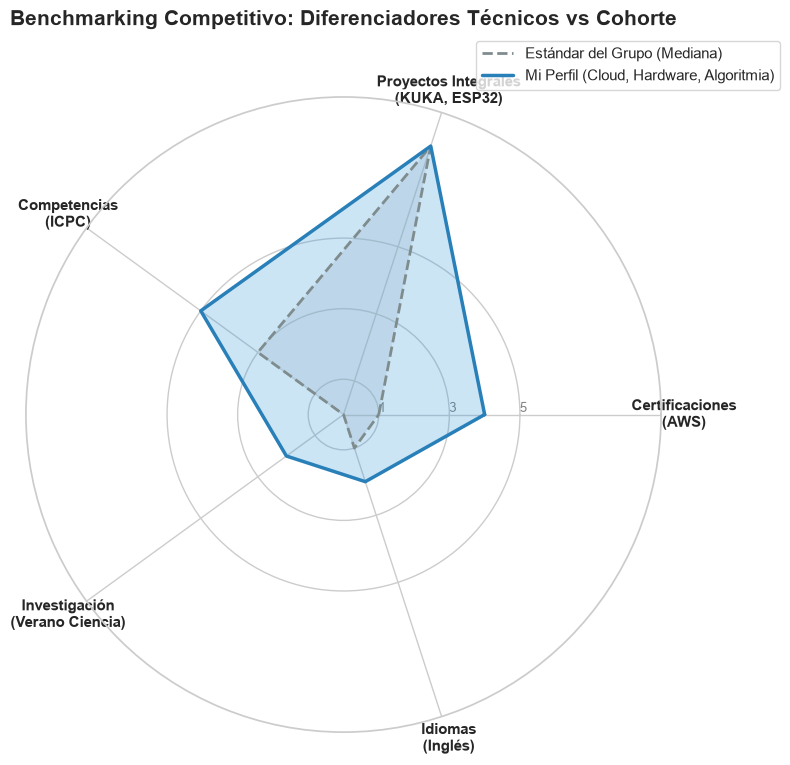

In [23]:
# 1. Seleccionar las 5 métricas que definen el valor agregado del perfil
categorias = ['certificaciones', 'proyectos_prototipo', 'icpc', 'verano_ciencia', 'idiomas']
N = len(categorias)

# 2. Extraer los datos y aplanarlos
valores_perfil = df_comparativo.loc[categorias, 'Mi_Perfil'].values.flatten().tolist()
valores_grupo = df_comparativo.loc[categorias, 'Mediana_Grupo'].values.flatten().tolist()

# 3. Repetir el primer valor al final para cerrar el polígono del radar
valores_perfil += valores_perfil[:1]
valores_grupo += valores_grupo[:1]

# 4. Calcular el ángulo de cada eje
angulos = [n / float(N) * 2 * pi for n in range(N)]
angulos += angulos[:1]

# 5. Inicializar la gráfica polar
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# 6. Dibujar la Mediana del Grupo (La referencia base)
ax.plot(angulos, valores_grupo, linewidth=2, linestyle='dashed', label='Estándar del Grupo (Mediana)', color='#7f8c8d')
ax.fill(angulos, valores_grupo, '#bdc3c7', alpha=0.3)

# 7. Dibujar Tu Perfil 
# Nota: La etiqueta incluye de manera sutil tus áreas fuertes (AWS, robótica, algoritmia)
ax.plot(angulos, valores_perfil, linewidth=2.5, linestyle='solid', label='Mi Perfil (Cloud, Hardware, Algoritmia)', color='#2980b9')
ax.fill(angulos, valores_perfil, '#3498db', alpha=0.25)

# 8. Añadir las etiquetas de cada eje
etiquetas_formateadas = ['Certificaciones\n(AWS)', 'Proyectos Integrales\n(KUKA, ESP32)', 'Competencias\n(ICPC)', 'Investigación\n(Verano Ciencia)', 'Idiomas\n(Inglés)']
plt.xticks(angulos[:-1], etiquetas_formateadas, size=11, fontweight='bold')

# 9. Diseño final
ax.set_rlabel_position(0)
plt.yticks([1, 3, 5], ["1", "3", "5"], color="grey", size=9) # Escala de referencia
plt.ylim(0, max(valores_perfil) + 1)
plt.title('Benchmarking Competitivo: Diferenciadores Técnicos vs Cohorte', size=15, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

# Mostrar y guardar la gráfica para tu presentación
plt.tight_layout()
plt.savefig('grafico_radar_perfil.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.2 Gráfico de Delta Competitivo
Esta visualización de barras horizontales aísla el cálculo `Mi_Perfil - Mediana_Grupo`. Los valores positivos (en azul) demuestran superioridad estadística inmediata, mientras que los negativos o nulos (en rojo) justifican la creación urgente del plan de acción estratégico del protocolo.

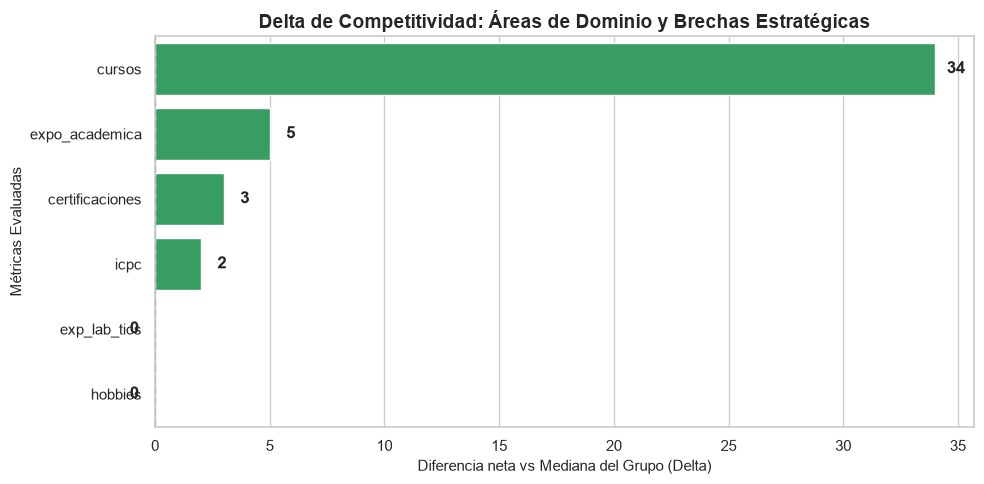

In [27]:
# 1. Seleccionar los top 4 puntos fuertes y el punto más débil
# Usamos pd.concat para unir el principio y el final de la tabla que ya ordenamos en la Fase 2
df_plot = pd.concat([df_comparativo_ordenado.head(4), df_comparativo_ordenado.tail(2)])

# 2. Configurar colores: Verde para ventaja (>0), Rojo para brecha (<=0)
colores = ['#27ae60' if val > 0 else '#e74c3c' for val in df_plot['Ventaja_Competitiva']]

# 3. Crear la gráfica (ACTUALIZADO para evitar el FutureWarning)
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Ventaja_Competitiva', 
                 y=df_plot.index, 
                 data=df_plot, 
                 hue=df_plot.index, 
                 palette=colores, 
                 legend=False)

# 4. Diseño y formato para el profesor
plt.title('Delta de Competitividad: Áreas de Dominio y Brechas Estratégicas', fontsize=14, fontweight='bold')
plt.xlabel('Diferencia neta vs Mediana del Grupo (Delta)', fontsize=11)
plt.ylabel('Métricas Evaluadas', fontsize=11)

# Añadir una línea vertical en el 0 para marcar la frontera de competitividad
plt.axvline(x=0, color='#2c3e50', linestyle='--', linewidth=1.5)

# 5. Añadir las etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(f"{p.get_width():.0f}", 
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='center', va='center', 
                xytext=(15 if p.get_width() > 0 else -15, 0), 
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_delta_competitivo.png', dpi=300, bbox_inches='tight')
plt.show()